# Tests a través de fragmentos de igual longitud (sliding window)

In [50]:
from assets import loadMelodic, select_files, corpora_parser, match_lengths, csv_export, csv_import, getSection, getPatternOcurrences
import ipywidgets as widgets
from music21 import *
from IPython.display import display
import pandas as pd
from nltk import FreqDist
from nltk.lm import Laplace, Vocabulary, MLE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from nltk.util import pad_sequence
import statistics
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import nltk.classify.util
from nltk.classify import NaiveBayesClassifier
from plotters import plt_individuals, plt_individuals_colored, plt_folded, plt_by_classes
from decouple import config, AutoConfig
import os
from itertools import product
from scipy import stats

## 1. Configuraciones genrales previas

#### 1.1 Parámetros sobre la extracción de features

In [51]:
# parámetros ajustables
n = 3
mode = 'Ii'
voice_selec= 1
stack = False
diatonic = False
base40=True

#### 1.2 Configuración de la carpeta donde se encuentran los datos (según el experimento)

In [52]:
# Atención: ejecutar este código. Define la carpeta donde se encuentra 
# la música en un archivo oculto .env y en las variables de entorno

config = AutoConfig(' ')
inp = input(f"La carpeta contenedora de la música es {config('MUSIC_FOLDER')}. Introduzca un nombre distinto o N, para conservar el nombre: ")

if inp.upper() != 'N':
    with open('.env', 'r') as f:
        lines = f.readlines()

    with open('.env', 'w') as f:
        for line in lines:
            if line.startswith('MUSIC_FOLDER='):
                f.write(f'MUSIC_FOLDER={inp}\n')
            else:
                f.write(line)
    os.environ['MUSIC_FOLDER'] = inp
else:
    os.environ['MUSIC_FOLDER'] = config('MUSIC_FOLDER')

La carpeta contenedora de la música es Music_files. Introduzca un nombre distinto o N, para conservar el nombre:  N


## 2. Selección de archivos y procesamiento, importación y/o exportación da datos

#### 2.1 Selección de archivos para cada dataset (compositor 1, compositor 2 y anónimos)

In [40]:
morales_fnames_and_others_pre = select_files(split_by_voices=True)
otros_fnames_and_others_pre = select_files(split_by_voices=True, multiple_folder_selection=True)
test_fnames_and_others_pre = select_files(split_by_voices=True)

Introduzca el nombre del directorio de obras a cargar:  Morales
El conjunto contiene obras clasificadas en 6 agrupaciones diferentes con [2, 3, 4, 5, 6, 7] voces. ¿Qué subset desea importar?  4


Los datasets disponibles son:

['Claudin', 'Consilium', 'Courtois', 'Daser', 'Escobedo', 'Festa', 'Gombert', 'Guerrero', 'Ivo', 'J. Gero', 'Jacotin', 'Jaquet of Mantua', 'Maistre Jhan', 'Palestrina', 'Peñalosa', 'Phinot', 'Ruffo', 'Verdelot', 'Willaert']


Introduzca los directorios de interés, escriba "OK" para terminar, simplemente "All" o "All-[carpeta a excluir]"":  All-Anon
El conjunto contiene obras clasificadas en 7 agrupaciones diferentes con [3, 4, 5, 6, 7, 8, 9] voces. ¿Qué subset desea importar?  4
Introduzca el nombre del directorio de obras a cargar:  Anon
El conjunto contiene obras clasificadas en 1 agrupaciones diferentes con [4] voces. ¿Qué subset desea importar?  4


#### 2.2 Extraer features de compositor 1: Morales

In [ ]:
## Aclaración de uso:
#Si queremos importar todos los archivos, independientemente de su plantilla musical, y tratar todas las voces indistintamente:
#stack=True, voice_selec=All, non_splitting=True.

morales = corpora_parser(n, morales_fnames_and_others, otros_fnames_and_others, diatonic=diatonic, base40=base40, stack=stack, mode=mode, voice_selec=voice_selec)
morales_words = morales[1]
morales_ngrams = morales[0]
morales_files = morales[3]
iors_hist = Counter(morales[2])

#### 2.3 Extraer features de compositor 2: Otros

In [ ]:
otros = corpora_parser(n, otros_fnames_and_others, morales_fnames_and_others, diatonic=diatonic, base40=base40, stack=stack, mode=mode, voice_selec=voice_selec)
otros_words = otros[1]
otros_ngrams = otros[0]
otros_files = otros[3]
iors_hist = Counter(otros[2])

#### 2.4 Extraer features de Problemáticos: Test (obligatorio)

In [65]:
test = corpora_parser(n, test_fnames_and_others_pre, test_fnames_and_others_pre, diatonic=diatonic, base40=base40, stack=stack, mode=mode, voice_selec=voice_selec)
test_ngrams = test[0]
test_files = test[3]

#### 2.5 Exportación de los datos en CSV

In [ ]:
csv_export(morales, composer='morales')
csv_export(otros, composer='otros')

#### 2.6 Importación de los datos de CSV

In [66]:
morales = csv_import('Exports/morales4v_3grams_Ii_voice-1_b40.csv.gz')
morales_ngrams = morales[0]
morales_files = morales[1]
morales_words = morales[2]
##
otros = csv_import('Exports/otros4v_3grams_Ii_voice-1_b40.csv.gz')
otros_ngrams = otros[0]
otros_files = otros[1]
otros_words = otros[2]

#### 2.7 Celda opcional (solo cuando analiza una voz)

In [67]:
## si hay un filtro de número de voces morales_fnames_and_others tendrá otra estructura, así que hay que re-declararlo
## por ahora se va a quedar así

names = [i[1] for i in morales_fnames_and_others_pre[0][4]]
files = [i[0] for i in morales_fnames_and_others_pre[0][4]]

morales_fnames_and_others = [files, voice_selec, files]

names = [i[1] for i in otros_fnames_and_others_pre[0][4]]
files = [i[0] for i in otros_fnames_and_others_pre[0][4]]

otros_fnames_and_others = [files, voice_selec, names]

names = [i[1] for i in test_fnames_and_others_pre[0][4]]
files = [i[0] for i in test_fnames_and_others_pre[0][4]]

test_fnames_and_others = [files, voice_selec, names]

#### 2.8 Data splitting

In [55]:
## 30% de compositor de entrenamiento para el test; 
# random_state=42 (en todas las ejecuciones la selección será igual)

x_train, x_test, y_train, y_test, z_train, z_test, n_train, n_test = train_test_split(morales_ngrams, morales_words, morales_files, morales_fnames_and_others[2], test_size=0.30, random_state=42)

#### 2.9 Carga del vocabularios de palabras y n-gramas: compositor 1 (train) y compositor 2 (completo)

In [56]:
vocabulario = [i for t in y_train for i in t]
vocabulario = Vocabulary(vocabulario)
vocabulario.update(['<s>', '</s>'])
###

vocabulario_otros = [i for t in otros_words for i in t]
vocabulario_otros = Vocabulary(vocabulario_otros)

### NGRAMAS

vocab_ngrams_mor = [i for t in x_train for i in t]
vocab_ngrams_mor = Vocabulary(vocab_ngrams_mor)

vocab_ngrams_otros = [i for t in otros_ngrams for i in t]
vocab_ngrams_otros = Vocabulary(vocab_ngrams_otros)

## 3. Fase de entrenamiento

#### 3.1 División de secuencias en ventanas de la longitud de la obra más corta

In [57]:
def ngram_sliding_windows(data, files, window_size=int(), step=1):
    out_data = list()
    out_files = list()
    for i, z in zip(data, files):
        for x in range(0, len(i)-window_size+1, step):
            out_data.append(i[x:x+window_size])
            out_files.append(z)
        
    return [out_data, out_files]


min_length = int(round(min([len(i) for i in morales_ngrams + otros_ngrams + test_ngrams])/2, 0))
morales_sliced_train_ngrams = ngram_sliding_windows(x_train, z_train, window_size=min_length, step=1)
morales_sliced_test_ngrams = ngram_sliding_windows(x_test, z_test, window_size=min_length, step=1)

otros_sliced_test_ngrams = ngram_sliding_windows(otros_ngrams, otros_files, window_size=min_length, step=1)
test_sliced_test_ngrams = ngram_sliding_windows(test_ngrams, test_files, window_size=min_length, step=1)

#### 3.2 Entrenamiento de modelo Laplace con conjuntos de misma longitud

In [58]:
model = Laplace(1)
model.fit(morales_sliced_train_ngrams[0], vocabulario)

#### 3.3 Test y extracciónn de perplejidades

In [59]:
pp_sliced = list()
#ent_sliced = list()
# no tenemos en cuenta la entropía

## morales y otros
current_f = otros_sliced_test_ngrams[1][0]
values = list()
## ngrams de morales, otros y test
## nombres de archivo de todos también
every_gram = otros_sliced_test_ngrams[0] + morales_sliced_test_ngrams[0] + test_sliced_test_ngrams[0]
every_file = otros_sliced_test_ngrams[1] + morales_sliced_test_ngrams[1] + test_sliced_test_ngrams[1]

for test, f in zip(every_gram, every_file):
    if current_f == f:
        values.append(model.perplexity(test))

    else:
        current_f = f
        pp_sliced.append(np.mean(values))
        values = list()
        values.append(model.perplexity(test))

pp_sliced.append(np.mean(values))


pp = list()
ent = list()

## morales y otros

for i, test in enumerate(otros_ngrams + x_test):
    pp.append(model.perplexity(test))
    ent.append(model.entropy(test))
    
# Perplejidades (pp) por cada clase
pp_morales = pp[len(otros_ngrams):]
pp_otros = pp[:len(otros_ngrams)]

## solo problematicos

pp_test = [model.perplexity(test) for test in test_ngrams]

## otros datos útiles más adelante, valores máximos, mínimos...

min_morales = np.min(pp_morales)
max_morales = np.max(pp_morales)
min_otros = np.min(pp_otros)
max_otros = np.max(pp_otros)
desviacion_morales = np.std(pp_morales)
desviacion_otros = np.std(pp_otros)
media_morales = np.mean(pp_morales)
media_otros = np.mean(pp_otros)

# Perplejidades (pp) por cada grupo

pp_morales_sliced = pp_sliced[len(otros_ngrams):-len(test_ngrams)]
pp_otros_sliced = pp_sliced[:len(otros_ngrams)]
pp_test_sliced = pp_sliced[-len(test_ngrams):]

## 4. Visión panorámica

#### 4.1 Perplejidad MEDIA por obra, agrupadas por autor (diferente color)

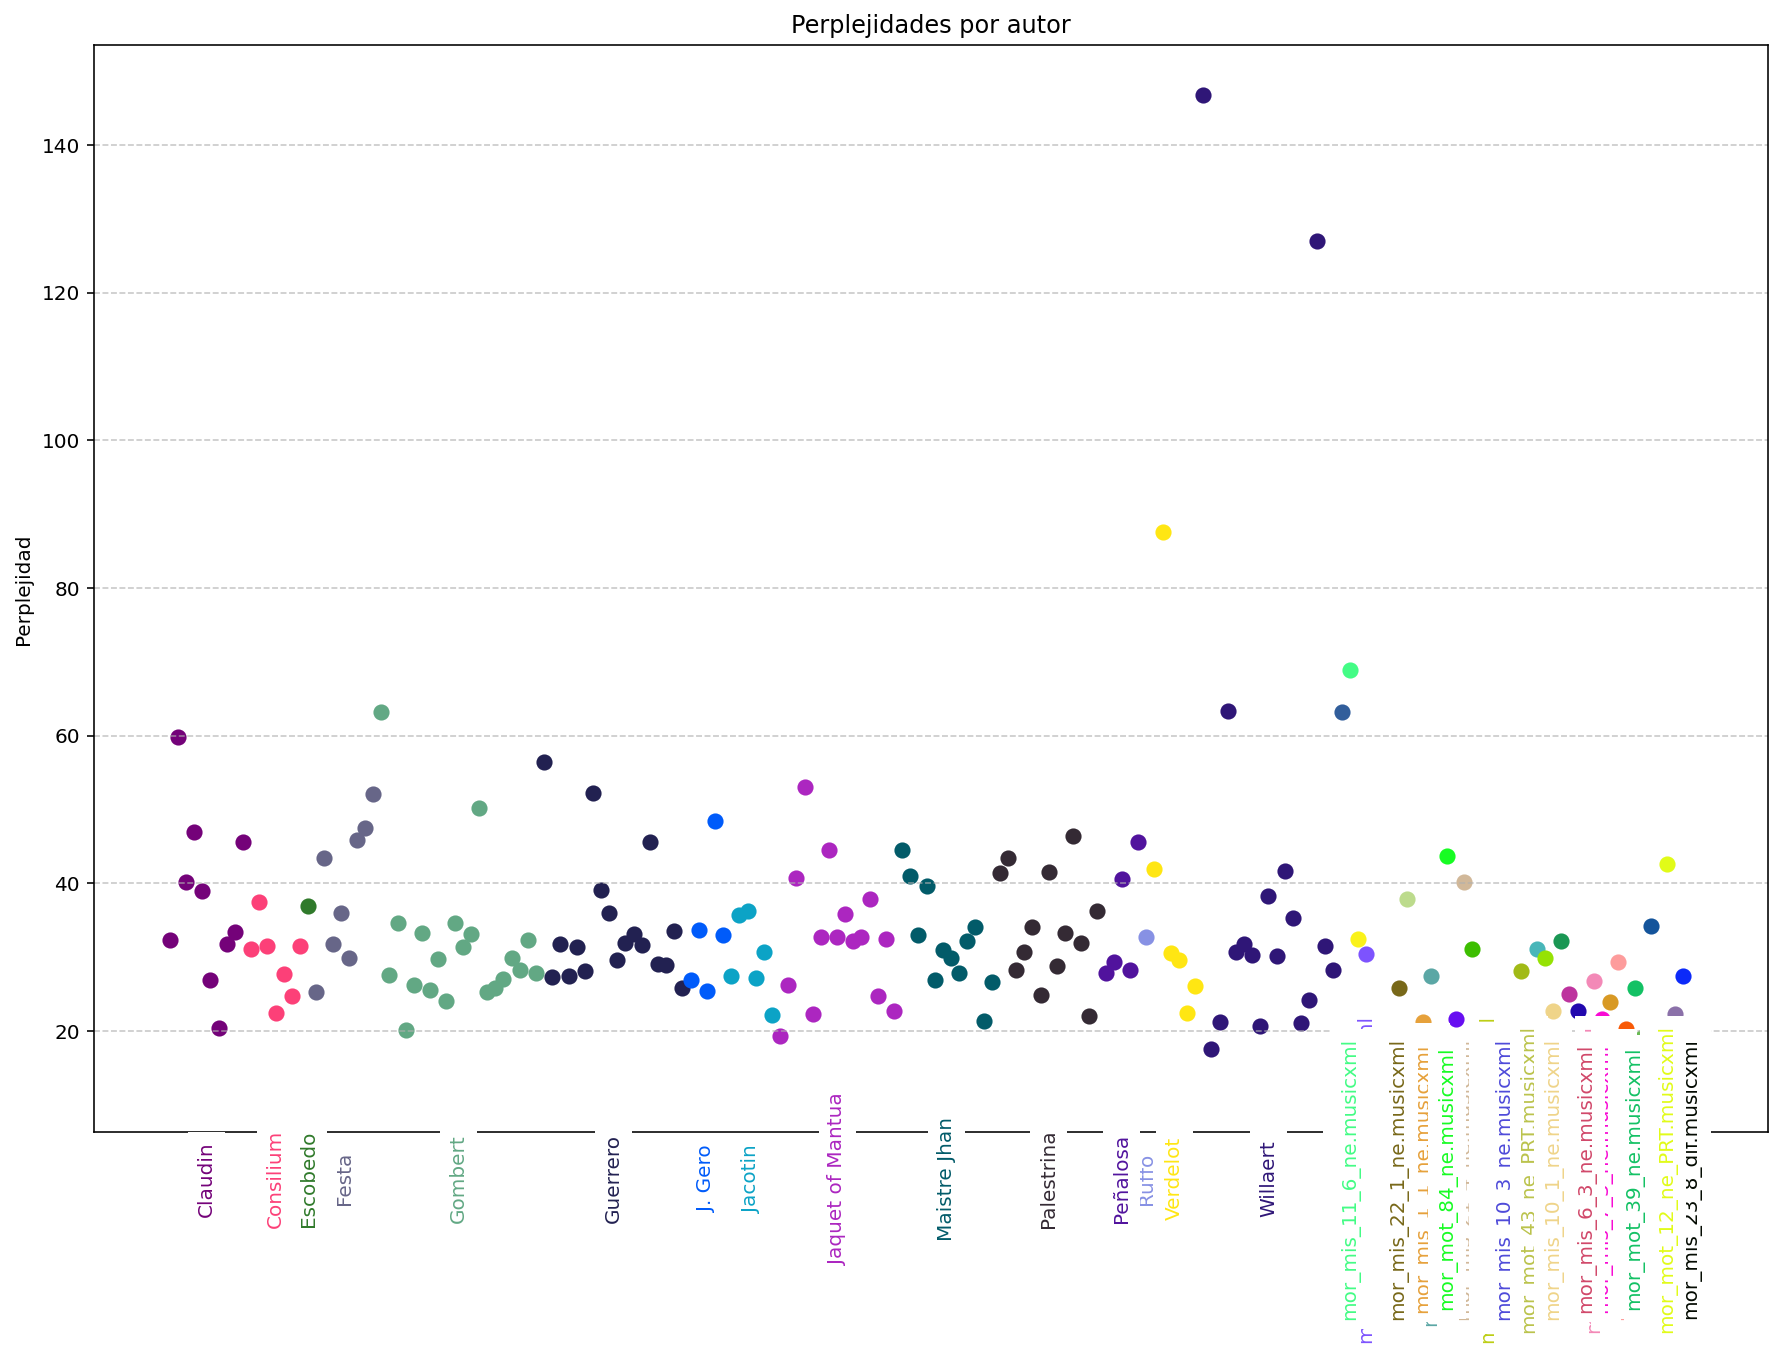

In [60]:
"""## tiene una apariencia horrenda, las siguientes mejoran. Demasiados archivos

grafico1 = plt_individuals(otros_files, z_test, pp)
plt.show()"""

grafico1 = plt_individuals_colored(otros_fnames_and_others[2], n_test, pp)
plt.show()

#### 4.2 Rangos de perplejidad en ambos datasets, con media y desviación típica

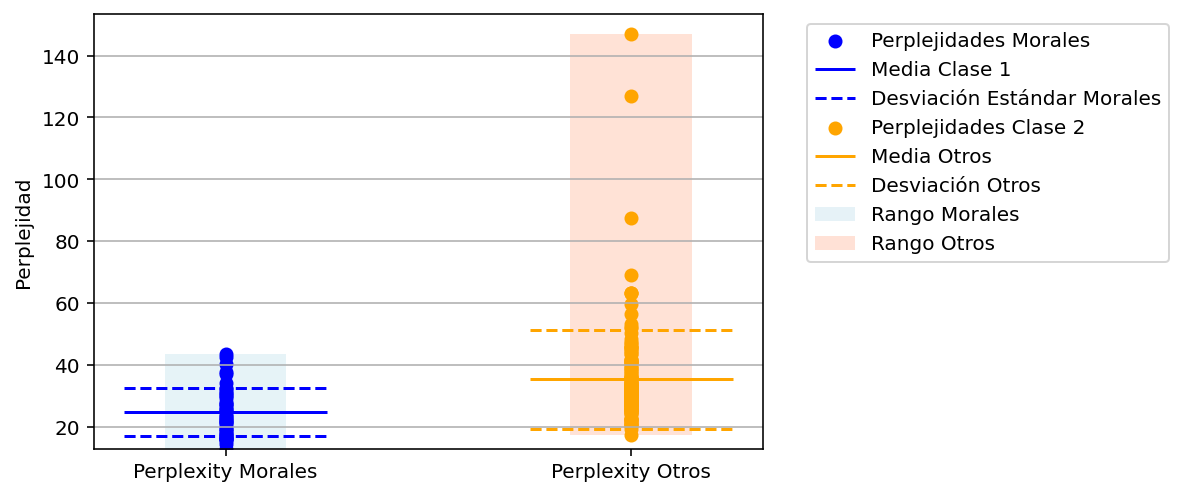

In [61]:
grafico2 = plt_by_classes(max_morales, max_otros, min_morales, min_otros, desviacion_morales, desviacion_otros, media_morales, media_otros, pp_morales, pp_otros)
grafico2.savefig('4v_sliding_folded_perplexities.svg')
## esta función no está muy bien desarrollada (temporal).

#### 4.3 Perplejidades autor, con media y desv. tip. + perplejidad media de obras anónimas 

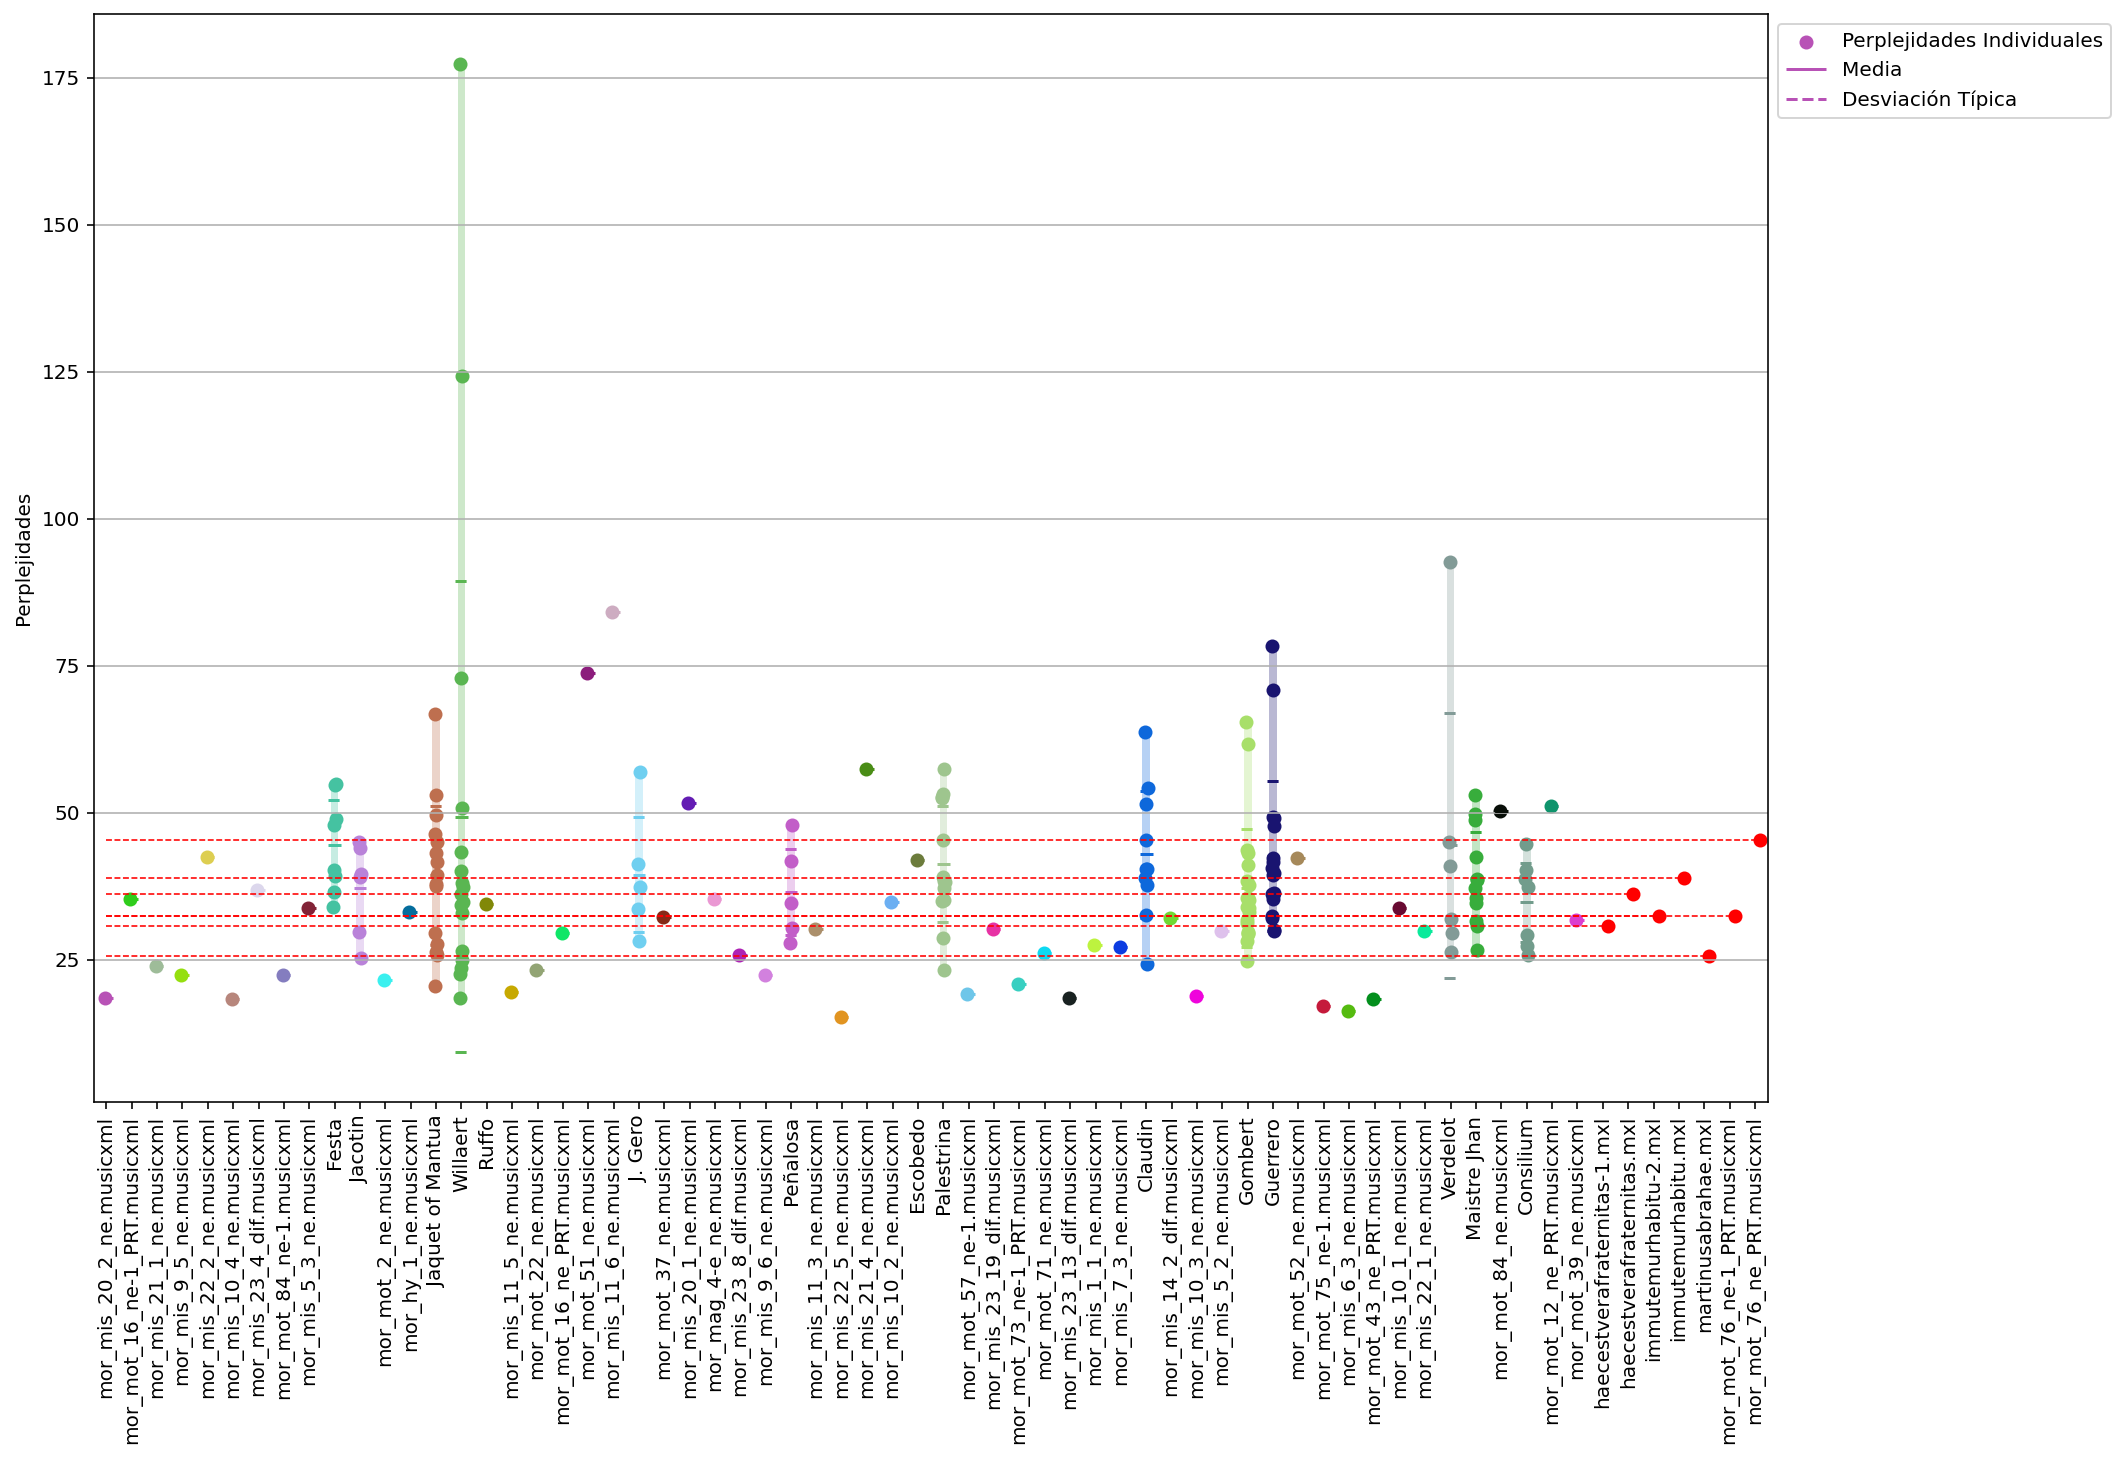

In [62]:
grafico3 = plt_folded(otros_fnames_and_others[2], n_test, pp_otros_sliced + pp_morales_sliced, test_files, pp_test_sliced)
grafico3.savefig('4v_sliding_perplexities.svg')

#### 4.4 ¿Se trata de distribuciones diferentes?

In [63]:
# 1. U de Mann Whitney

estadistico_u, p_valor = stats.mannwhitneyu(pp_morales_sliced, pp_otros_sliced)
nivel_significancia = 0.05

print("Estadístico U:", estadistico_u)
print("p-valor:", p_valor)

if p_valor < nivel_significancia:
    print("Las muestras pertenecen a distribuciones diferentes (p < {:.2f}).".format(nivel_significancia))
else:
    print("No hay evidencia suficiente para concluir que las muestras pertenecen a entidades diferentes (p >= {:.2f}).".format(nivel_significancia))

Estadístico U: 1477.0
p-valor: 5.817486741311237e-08
Las muestras pertenecen a distribuciones diferentes (p < 0.05).


In [64]:
# 2. T de Student

estadistico_t, p_valor = stats.ttest_ind(pp_morales_sliced, pp_otros_sliced)

nivel_significancia = 0.05

print("Estadístico T:", estadistico_t)
print("p-valor:", p_valor)

if p_valor < nivel_significancia:
    print("Las muestras pertenecen a distribuciones diferentes (p < {:.2f}).".format(float(nivel_significancia)))
else:
    print("No hay evidencia suficiente para concluir que las muestras pertenecen a entidades diferentes (p >= {:.2f}).".format(nivel_significancia))

Estadístico T: -4.257297704854971
p-valor: 3.2637408043178035e-05
Las muestras pertenecen a distribuciones diferentes (p < 0.05).


## 5. Análisis multi-resolución por diferentes logitudes
### Descendiendo a partir de la longitud de la obra más corta

#### 5.1 Almacenamiento de los datos fragmentados con distintas longitudes

In [18]:
pp_every_length_otros = dict()
pp_every_length_mor = dict()

min_l = int(round(min([len(i) for i in x_test + otros_ngrams]), 0))

for l in range(min_l, 1, -1):

    morales_sliced_train_ngrams = ngram_sliding_windows(x_train, z_train, window_size=l, step=1)
    morales_sliced_test_ngrams = ngram_sliding_windows(x_test, z_test, window_size=l, step=1)

    otros_sliced_test_ngrams = ngram_sliding_windows(otros_ngrams, otros_files, window_size=l, step=1)
    ## modelo nuevo en cada iteración
    model = Laplace(1)
    model.fit(morales_sliced_train_ngrams[0], vocabulario)

    pp_sliced_mor = list()
    pp_sliced_otros = list()

    ## morales y otros
    current_f = otros_sliced_test_ngrams[1][0]
    ## ngrams de morales, otros y test
    every_gram = otros_sliced_test_ngrams[0] + morales_sliced_test_ngrams[0]

    for n, test in enumerate(every_gram):
        if n < len(otros_sliced_test_ngrams[0]):
            pp_sliced_otros.append(model.perplexity(test))
        else:
            pp_sliced_mor.append(model.perplexity(test))
        
    
    pp_every_length_otros[l] = pp_sliced_otros
    pp_every_length_mor[l] = pp_sliced_mor

#### 5.2 Comparación de media, desv. típ., moda, valor máximo y mínimo de perplejidades para cada longitud en compositor 1

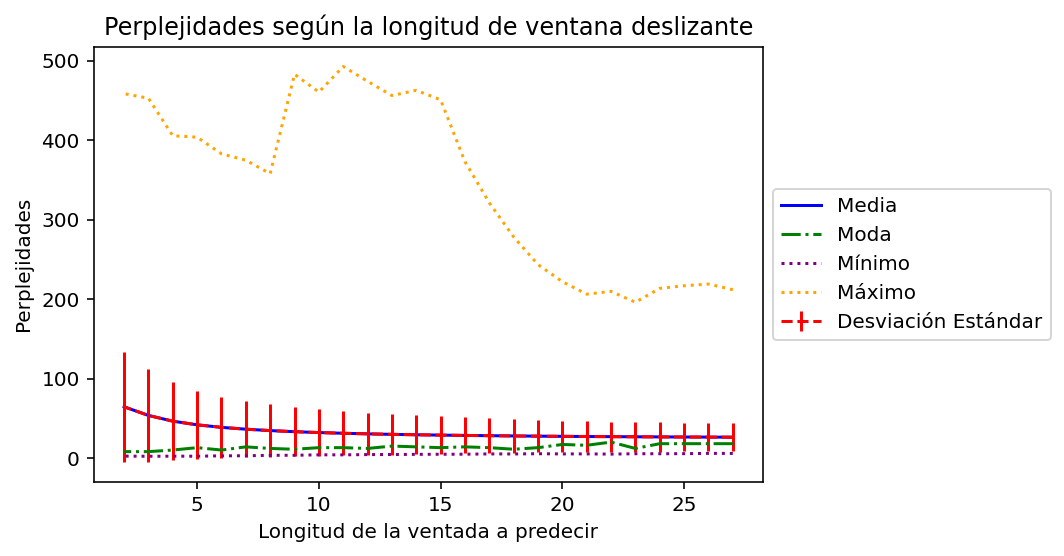

In [19]:
lengths_mor = pp_every_length_mor.keys()
pp_lengths_mor = pp_every_length_mor.values()

x = list(lengths_mor)

y = list(pp_lengths_mor)

media_por_momento_mor = []
desviacion_estandar_por_momento_mor = []
moda_por_momento_mor = []
minimos_mor = []
maximos_mor = []

for moment in y:
    media_por_momento_mor.append(np.mean(moment))
    desviacion_estandar_por_momento_mor.append(np.std(moment))
    moda_por_momento_mor.append(np.argmax(np.bincount(moment)))
    minimos_mor.append(np.min(moment))
    maximos_mor.append(np.max(moment))
    
media_por_momento_mor = np.array(media_por_momento_mor)
desviacion_estandar_por_momento_mor = np.array(desviacion_estandar_por_momento_mor)
moda_por_momento_mor = np.array(moda_por_momento_mor)
minimos_mor = np.array(minimos_mor)
maximos_mor = np.array(maximos_mor)


plt.plot(x[:len(media_por_momento_mor)], media_por_momento_mor, label='Media', color='blue')

plt.errorbar(x[:len(desviacion_estandar_por_momento_mor)], media_por_momento_mor, yerr=desviacion_estandar_por_momento_mor, linestyle='--', label='Desviación Estándar', color='red')

plt.plot(x[:len(moda_por_momento_mor)], moda_por_momento_mor, linestyle='-.', label='Moda', color='green')

plt.plot(x[:len(minimos_mor)], minimos_mor, linestyle=':', label='Mínimo', color='purple')

plt.plot(x[:len(maximos_mor)], maximos_mor, linestyle=':', label='Máximo', color='orange')

plt.xlabel('Longitud de la ventada a predecir')
plt.ylabel('Perplejidades')
plt.title('Perplejidades según la longitud de ventana deslizante')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

#### 5.3 Comparación de media, desv. típ., moda, valor máximo y mínimo de perplejidades para cada longitud en compositor 2

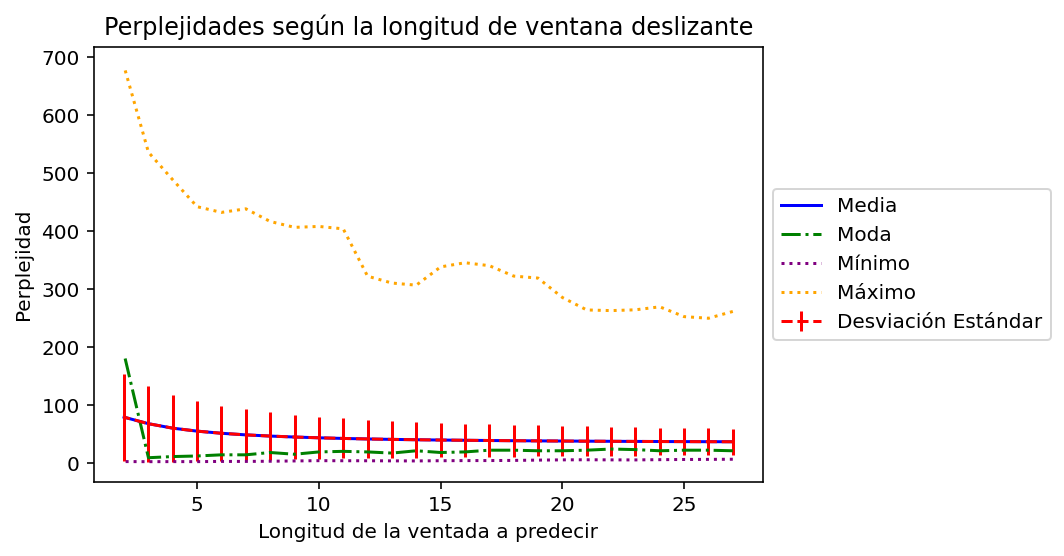

In [20]:
lengths_otros = pp_every_length_otros.keys()
pp_lengths_otros = pp_every_length_otros.values()

x = list(lengths_otros)

y = list(pp_lengths_otros)

media_por_momento_otros = []
desviacion_estandar_por_momento_otros = []
moda_por_momento_otros = []
minimos_otros = []
maximos_otros = []

for moment in y:
    media_por_momento_otros.append(np.mean(moment))
    desviacion_estandar_por_momento_otros.append(np.std(moment))
    moda_por_momento_otros.append(np.argmax(np.bincount(moment)))
    minimos_otros.append(np.min(moment))
    maximos_otros.append(np.max(moment))
    
media_por_momento_otros = np.array(media_por_momento_otros)
desviacion_estandar_por_momento_otros = np.array(desviacion_estandar_por_momento_otros)
moda_por_momento_otros = np.array(moda_por_momento_otros)
minimos_otros = np.array(minimos_otros)
maximos_otros = np.array(maximos_otros)


plt.plot(x[:len(media_por_momento_otros)], media_por_momento_otros, label='Media', color='blue')

plt.errorbar(x[:len(desviacion_estandar_por_momento_otros)], media_por_momento_otros, yerr=desviacion_estandar_por_momento_otros, linestyle='--', label='Desviación Estándar', color='red')

plt.plot(x[:len(moda_por_momento_otros)], moda_por_momento_otros, linestyle='-.', label='Moda', color='green')

plt.plot(x[:len(minimos_otros)], minimos_otros, linestyle=':', label='Mínimo', color='purple')

plt.plot(x[:len(maximos_otros)], maximos_otros, linestyle=':', label='Máximo', color='orange')

plt.xlabel('Longitud de la ventada a predecir')
plt.ylabel('Perplejidad')
plt.title('Perplejidades según la longitud de ventana deslizante')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

## 6. Buscar qué fragmentos (longitud seleccionada) son mejor y peor predichos

#### 6.1 Data splitting para morales, otros y test + entrenamiento del modelo.

In [21]:
### LONGITUD ÓPTIMA SELECCIONADA
## en este caso, es int(round(min([len(i) for i in morales_ngrams + otros_ngrams + test_ngrams])/2, 0))
long = int(round(min([len(i) for i in morales_ngrams + otros_ngrams + test_ngrams])/2, 0))

test_sliced_test_ngrams_exper1 = ngram_sliding_windows(test_ngrams, test_files, window_size=long, step=1)

morales_sliced_train_ngrams_exper1 = ngram_sliding_windows(x_train, z_train, window_size=long, step=1)

morales_sliced_test_ngrams_exper1 = ngram_sliding_windows(x_test, z_test, window_size=long, step=1)

otros_sliced_exper1 = ngram_sliding_windows(otros_ngrams, otros_files, window_size=long, step=1)

model = Laplace(1)
model.fit(morales_sliced_train_ngrams_exper1[0], vocabulario)

#### 6.2 Cálculo de perplejidades para longitud 21 morales
También se calcula:
1. La media
2. Desviación típica como umbral para mejores y peores predicciones.

In [22]:
pp = dict()
crt = None

for n, f in enumerate(morales_sliced_test_ngrams_exper1[1]):
    if crt is None:
        crt = f
        pp[f] = [model.perplexity(morales_sliced_test_ngrams_exper1[0][n])]
    elif crt == f:
        if pp[f]:
            pp[f].append(model.perplexity(morales_sliced_test_ngrams_exper1[0][n]))
        else:
            pp[f] = [model.perplexity()]
    else:
        crt = f
        pp[f] = [model.perplexity(morales_sliced_test_ngrams_exper1[0][n])]

media_longitud_optima = media_por_momento_otros[long-1]
dev1_longitud_optima = desviacion_estandar_por_momento_otros[long-1] + media_longitud_optima
dev2_longitud_optima = dev1_longitud_optima - desviacion_estandar_por_momento_otros[long-1] *2

#### 6.3 Localización de perplejidades (index) < desviación típica (mejores predicciones)

In [23]:
high_indexes = {k: [e for i, e in zip(v, range(len(v))) if i < dev2_longitud_optima] for k, v in pp.items()}
output_high = dict()

for i in high_indexes.keys():
    positions = list()
    active = False
    before = None
    out = list()
    l = len(high_indexes[i])
    for n, v in enumerate(high_indexes[i]):
        
        if active:
            if v < before+long:
                if n == l-1:
                    positions.append(v)
                    out.append(positions[:])
                else:
                    before = v

            else:
                positions.append(before)
                out.append(positions[:])
                positions.clear()
                positions.append(v)
                active = True
                before = v
        else:
            if before:
                active = True
                before = v

            else:
                active = True
                before = v
                positions.append(v)
    
    if len(out) == 1 and out[0][1] == len(pp[i])-1:
        output_high[i] = 'Full'
    else:
        output_high[i] = out

#### 6.4 Localización de perplejidades (index) > desviación típica (peores predicciones)

In [24]:
low_indexes = {k: [e for i, e in zip(v, range(len(v))) if i > dev1_longitud_optima] for k, v in pp.items()}
output_low = dict()

for i in low_indexes.keys():
    positions = list()
    active = False
    before = None
    out = list()
    l = len(low_indexes[i])
    for n, v in enumerate(low_indexes[i]):
        
        if active:
            if v < before+long:
                if n == l-1:
                    positions.append(v)
                    out.append(positions[:])
                else:
                    before = v

            else:
                positions.append(before)
                out.append(positions[:])
                positions.clear()
                positions.append(v)
                active = True
                before = v
        else:
            if before:
                active = True
                before = v

            else:
                active = True
                before = v
                positions.append(v)
    
    if len(out) == 1 and out[0][1] == len(pp[i])-1:
        output_low[i] = 'Full'
    else:
        output_low[i] = out

#### 6.5 Imprimir partes mejor predichas para Morales

In [25]:
best_ngrams = list()
best_words = list()
n = 3

for c, (k, v) in enumerate(output_high.items()):
    length = len(pp[k])
    if isinstance(v, str):
        continue
    if len(v) == 0:
        continue
        
    for vv in v:
        pos1 = vv[0]-n+1
        pos2 = vv[1]-n+1 
        if pos1 < 0:
            
            #score = getSection(f"{os.environ['MUSIC_FOLDER']}/Morales/{k}", 1, 0, pos2+long+n-1)
            temp = y_test[c][:pos2+long+n-1]
            #score[1].insert(0, metadata.Metadata())
            #score[1].metadata.title = 'Measures span: ' + '-'.join(str(i) for i in score[0]) + ' // Indexes: ' + str(score[2]) + '-' + str(score[3])
            best_words.append(temp)
            best_ngrams.append(list(nltk.ngrams(temp,n)))
            #print(temp)
            #score[1].show()
            
        else:
            try:
                #score = getSection(f"{os.environ['MUSIC_FOLDER']}/Morales/{k}", 1, pos1, pos2+long+n-1)
                temp = y_test[c][pos1:pos2+long+n-1]
            except:
                #score = getSection(f"{os.environ['MUSIC_FOLDER']}/Morales/{k}", 1, pos1, pos2+long)
                temp = y_test[c][pos1:pos2+long]
            #score[1].insert(0, metadata.Metadata())
            #score[1].metadata.title = 'Measures span: ' + '-'.join(str(i) for i in score[0]) + ' // Indexes: ' + str(score[2]) + '-' + str(score[3])
            best_words.append(temp)
            best_ngrams.append(list(nltk.ngrams(temp,n)))
            #print(temp)
            #score[1].show()

#### 6.6 Imprimir partes peor predichas para Morales

In [26]:
worst_ngrams = list()
worst_words = list()
n = 3

for c, (k, v) in enumerate(output_low.items()):
    length = len(pp[k])
    
    if isinstance(v, str):
        continue
    if len(v) == 0:
        continue
        
    for vv in v:
        pos1 = vv[0]-n+1
        pos2 = vv[1]-n+1 
        if pos1 < 0:
            
            #score = getSection(f"{os.environ['MUSIC_FOLDER']}/Morales/{k}", 1, 0, pos2+long+n-1)
            temp = y_test[c][:pos2+long+n-1]
            #score[1].insert(0, metadata.Metadata())
            #score[1].metadata.title = 'Measures span: ' + '-'.join(str(i) for i in score[0]) + ' // Indexes: ' + str(score[2]) + '-' + str(score[3])
            worst_words.append(temp)
            worst_ngrams.append(list(nltk.ngrams(temp,n)))
            #score[1].show()
            
        else:
            try:
                #score = getSection(f"{os.environ['MUSIC_FOLDER']}/Morales/{k}", 1, pos1, pos2+long+n-1)
                temp = y_test[c][pos1:pos2+long+n-1]
            except:
                #score = getSection(f"{os.environ['MUSIC_FOLDER']}/Morales/{k}", 1, pos1, pos2+long)
                temp = y_test[c][pos1:pos2+long]
            #score[1].insert(0, metadata.Metadata())
            #score[1].metadata.title = 'Measures span: ' + '-'.join(str(i) for i in score[0]) + ' // Indexes: ' + str(score[2]) + '-' + str(score[3])
            worst_words.append(temp)
            worst_ngrams.append(list(nltk.ngrams(temp,n)))
            #score[1].show()

## 7. Comparación del vocabulario de los fragmentos seleccionados con el general de Morales (train) y otros

#### 7.1 Comparación con vocabulario (palabras) más común de Morales con Otros 

In [27]:
best_words_unique = list()

for i in best_words:
    for x in i:
        if x in best_words_unique:
            continue
        else:best_words_unique.append(x)

data = []

for i in best_words_unique:
    
    dist = vocabulario[i] - vocabulario_otros[i]
    
    if dist < 0:dist = dist*-1

    data.append({'Word': i, 'Morales': vocabulario[i], 'Otros': vocabulario_otros[i], 'Distance': dist})

pd.set_option('display.max_rows', 50)
df = pd.DataFrame(data)
df = df.sort_values(by='Distance')

display(df.reset_index())

,index,Word,Morales,Otros,Distance
0,18,ZO,1316,1315,1
1,83,H{,3,4,1
2,85,Dr,14,13,1
3,75,fl,3,1,2
4,21,hI,965,967,2
...,...,...,...,...,...
96,8,FU,861,1104,243
97,12,fO,445,697,252
98,9,fI,694,1116,422
99,11,<R><R>,1213,1640,427


#### 7.2 Comparación con vocabulario (palabras) menos común de Morales con Otros 

In [28]:
worst_words_unique = list()

for i in worst_words:
    for x in i:
        if x in worst_words_unique:
            continue
        else:worst_words_unique.append(x)

data = []

for i in worst_words_unique:
    
    dist = vocabulario[i] - vocabulario_otros[i]
    
    if dist < 0:dist = dist*-1

    data.append({'Word': i, 'Morales': vocabulario[i], 'Otros': vocabulario_otros[i], 'Distance': dist})

pd.set_option('display.max_rows', 20)
df = pd.DataFrame(data)
df = df.sort_values(by='Distance')

display(df.reset_index())

,index,Word,Morales,Otros,Distance
0,119,Da,0,0,0
1,56,GD,0,0,0
2,83,Zm,0,0,0
3,112,cC,13,13,0
4,102,hr,9,8,1
...,...,...,...,...,...
119,5,FU,861,1104,243
120,20,fO,445,697,252
121,8,fI,694,1116,422
122,18,<R><R>,1213,1640,427


#### 7.3 Comparación con vocabulario (n-gramas) más común de Morales con Otros

In [29]:
best_ngrams_unique = list()

for i in best_ngrams:
    for x in i:
        if x in best_ngrams_unique:
            continue
        else:best_ngrams_unique.append(x)
        
data = []

for i in best_ngrams_unique:
    
    dist = vocab_ngrams_mor[i] - vocab_ngrams_otros[i]
    if dist < 0:dist = dist*-1

    data.append({'Word': i, 'Morales': vocab_ngrams_mor[i], 'Otros': vocab_ngrams_otros[i], 'Distance': dist})

pd.set_option('display.max_rows', 20)
df = pd.DataFrame(data)
df = df.sort_values(by='Distance')

display(df.reset_index())    


,index,Word,Morales,Otros,Distance
0,259,"(F,, cI, hI)",0,0,0
1,465,"(fl, fU, ZU)",0,0,0
2,912,"(FJ, <R><R>, fC)",3,3,0
3,910,"(i&, ZU, ZU)",0,0,0
4,466,"(ZD, FT, FJ)",1,1,0
...,...,...,...,...,...
1105,51,"(iJ, ZI, FU)",61,24,37
1106,397,"(hI, IO, fI)",24,61,37
1107,152,"(fI, FU, <R><R>)",25,75,50
1108,241,"(fO, ZO, ZO)",89,37,52


#### 7.4 Comparación con vocabulario (palabras) menos común de Morales con Otros 

In [30]:
worst_ngrams_unique = list()

for i in worst_ngrams:
    for x in i:
        if x in worst_ngrams_unique:
            continue
        else:worst_ngrams_unique.append(x)

data = []

for i in worst_ngrams_unique:
    
    dist = vocab_ngrams_mor[i] - vocab_ngrams_otros[i]
    
    if dist < 0:dist = dist*-1

    data.append({'Word': i, 'Morales': vocab_ngrams_mor[i], 'Otros': vocab_ngrams_otros[i], 'Distance': dist})

pd.set_option('display.max_rows', 20)
df = pd.DataFrame(data)
df = df.sort_values(by='Distance')

display(df.reset_index())

,index,Word,Morales,Otros,Distance
0,893,"(HT, <R><R>, h&)",0,0,0
1,343,"(fI, FI, FU)",0,0,0
2,342,"(FO, fI, FI)",0,0,0
3,858,"(Zr, F{, ZD)",0,0,0
4,859,"(F{, ZD, ZT)",0,0,0
...,...,...,...,...,...
1178,593,"(iI, ZI, FU)",52,17,35
1179,939,"(hI, IO, fI)",24,61,37
1180,210,"(fI, FU, <R><R>)",25,75,50
1181,541,"(fO, ZO, ZO)",89,37,52


# (*) Matrices de similitud vocabulario de mejores palabras y n-gramas

In [31]:
flattered_best_words = [t for i in best_words for t in i]
flattered_worst_words = [t for i in worst_words for t in i]

niveles = test_words
archivos = test_files
N = len(archivos)
present_best_words = list()
present_worst_words = list()
conteo_palabras = {"best_words": [], "worst_words": []}

for i in range(N):
    set_nivel = set(niveles[i])
    conteo_palabras["best_words"].append(len(set_nivel.intersection(set(flattered_best_words))))
    conteo_palabras["worst_words"].append(len(set_nivel.intersection(set(flattered_worst_words))))
    present_best_words.append(set_nivel.intersection(set(flattered_best_words)))
    present_worst_words.append(set_nivel.intersection(set(flattered_best_words)))
df_conteo = pd.DataFrame(conteo_palabras, index=archivos)

display(df_conteo)

,best_words,worst_words
haecestverafraternitas-1.mxl,45,46
haecestverafraternitas.mxl,54,53
immutemurhabitu-2.mxl,51,52
immutemurhabitu.mxl,52,55
martinusabrahae.mxl,50,50
mor_mot_76_ne-1_PRT.musicxml,36,36
mor_mot_76_ne_PRT.musicxml,44,44


In [32]:
flattered_best_ngrams = [t for i in best_ngrams for t in i]
flattered_worst_ngrams = [t for i in worst_ngrams for t in i]

niveles = test_ngrams
archivos = test_files
N = len(archivos)

present_best_ngrams = list()
present_worst_ngrams = list()
conteo_palabras = {"best_ngrams": [], "worst_ngrams": []}

for i in range(N):
    set_nivel = set(niveles[i])
    conteo_palabras["best_ngrams"].append(len(set_nivel.intersection(set(flattered_best_ngrams))))
    conteo_palabras["worst_ngrams"].append(len(set_nivel.intersection(set(flattered_worst_ngrams))))
    present_best_ngrams.append(set_nivel.intersection(set(flattered_best_ngrams)))
    present_worst_ngrams.append(set_nivel.intersection(set(flattered_best_ngrams)))
df_conteo = pd.DataFrame(conteo_palabras, index=archivos)

display(df_conteo)

,best_ngrams,worst_ngrams
haecestverafraternitas-1.mxl,35,22
haecestverafraternitas.mxl,59,25
immutemurhabitu-2.mxl,51,28
immutemurhabitu.mxl,60,29
martinusabrahae.mxl,52,30
mor_mot_76_ne-1_PRT.musicxml,35,13
mor_mot_76_ne_PRT.musicxml,27,13


In [33]:
present_best_ngrams

[{('DJ', 'hI', 'IO'),
  ('DU', 'hU', 'FT'),
  ('FT', '<R><R>', 'fO'),
  ('FT', 'DJ', 'hI'),
  ('FT', 'iJ', 'ZI'),
  ('FU', 'ZI', '<R><R>'),
  ('II', 'fJ', 'ZT'),
  ('IO', 'fJ', 'DT'),
  ('IO', 'fJ', 'FT'),
  ('IO', 'fJ', 'YT'),
  ('IO', 'fJ', 'ZT'),
  ('ZC', 'ZU', 'ZU'),
  ('ZD', 'ZU', 'ZT'),
  ('ZI', 'II', '<R><R>'),
  ('ZI', 'IO', 'fJ'),
  ('ZI', 'ZU', 'ZU'),
  ('ZT', 'ZU', 'HU'),
  ('ZT', 'fJ', 'ZI'),
  ('ZU', 'FT', 'iJ'),
  ('ZU', 'HU', 'hI'),
  ('ZU', 'ZT', 'ZU'),
  ('ZU', 'ZU', 'FT'),
  ('ZU', 'ZU', 'ZT'),
  ('ZU', 'ZU', 'ZU'),
  ('ZU', 'fC', 'ZU'),
  ('ZU', 'fI', 'ZU'),
  ('fC', 'ZU', 'ZU'),
  ('fI', 'DJ', 'hI'),
  ('fI', 'DU', 'hU'),
  ('fJ', 'FT', '<R><R>'),
  ('fJ', 'IT', '<R><R>'),
  ('hI', 'II', 'fJ'),
  ('hI', 'IO', 'fJ'),
  ('hU', 'FT', 'DJ'),
  ('hU', 'ZT', 'ZU')},
 {('<R><R>', 'ZO', 'fI'),
  ('<R><R>', 'ZT', 'fJ'),
  ('<R><R>', 'fO', 'ZO'),
  ('DI', 'hI', 'IO'),
  ('DJ', 'hT', 'FU'),
  ('DT', 'yJ', 'ZI'),
  ('DU', 'hI', 'II'),
  ('DU', 'hU', 'FT'),
  ('DZ', 'hU', 'FU'),

## 8. Búsqueda en un solo archivo problemático

#### Mejores y peores n-gramas aplanados y contados

In [34]:
best_ngrams_flattened = Counter([" ".join(x) for i in best_ngrams for x in i])
worst_ngrams_flattened = Counter([" ".join(x) for i in worst_ngrams for x in i])

In [35]:
seq1 = pd.Series(best_ngrams_flattened.keys())
counts1 = pd.Series(best_ngrams_flattened.values())
df = pd.concat([seq1, counts1], axis=1).reset_index()
df.columns = ['Index', 'Sequence', 'Count']
display(df)
#display(df.style.set_caption("Best n-grams counter"))

,Index,Sequence,Count
0,0,Z! DT hJ,1
1,1,DT hJ ZI,5
2,2,hJ ZI ZI,8
3,3,ZI ZI fU,1
4,4,ZI fU ZU,1
...,...,...,...
1105,1105,FZ fJ FT,1
1106,1106,<R><R> fx ZT,1
1107,1107,fx ZT F!,1
1108,1108,ZT F! fJ,1


In [36]:
df = pd.DataFrame.from_dict(worst_ngrams_flattened, orient='index').reset_index()
display(df.style.set_caption("Worst n-grams counter"))

,index,0
0,ZI ZJ HI,1
1,ZJ HI fT,1
2,HI fT hD,1
3,fT hD FU,1
4,hD FU ZT,1
5,FU ZT FJ,2
6,ZT FJ fI,1
7,FJ fI IU,1
8,fI IU ZU,1
9,IU ZU cZ,1


In [27]:
text = widgets.Text(
    value='',
    placeholder='Enter composer name',
    description='Name:',
    disabled=False
)

text2 = widgets.Text(
    value='',
    placeholder='Enter file name',
    description='File:',
    disabled=False
)

text3 = widgets.Text(
    value='',
    placeholder='Browse sequences',
    description='Pattern:',
    disabled=False
)

botones = widgets.RadioButtons(
    options=['Exact match', 'Truncated match'],
    value='Exact match',
    description='Settings:',
    disabled=False
)

button = widgets.Button(
    description='Submit',
    disabled=False,
    button_style='',
    icon='check'
)

output = widgets.Output()

def getConsecutive(pattern, seq, comp, wildcards, voice):
    ## validar patrón
    if wildcards == 'Wildcards':
        wildcards = True
    else:wildcards = False
    
    data = corpora_parser(4, [[seq],'All',[comp],''], 
                         ['']*4, base40=base40, stack=stack, mode=mode, voice_selec=voice)[1][0]
    
    dct = dict()
    
    if len(pattern.split()) == 1:
        temp = [i for i in range(len(seq)) if data[i] == pattern.split()[0]]
        return temp
        
    for e in pattern.split():
        
        temp = [i for i in range(len(data)) if data[i] == e]
        dct[e] = temp
        
    indexes = list()
    
    values = list(dct.values())
    for i in product(*values):
        condition = None
        for n, x in enumerate(i):

            if condition is False:
                break
                
            if n < len(i)-1:
                pass
            else:break
            
            if i[n+1] == x+1:
                condition = True
                
            else:
                if wildcards is True:
                    if i[n+1] == x+2:
                        condition = True
                        
                    else:
                        condition = False
                        break
                        
                        
                else:
                    condition = False
                    break
                    
        if condition is False:
            pass
        else:
            indexes.append(list(i))

    print(data)
    print(indexes)
    if len(indexes) == 0:
        print('Sin resultados')
        pass
    else:
        out = getPatternOcurrences(f"{os.environ['MUSIC_FOLDER']}/{comp}/{seq}", voice, indexes)
        ## out.show() pero no quiero esto ahora
        fp = out.write('musicxml', fp=f'{pattern}_{seq}_out.musicxml')
        
def on_button_clicked(b):
    with output:
        output.clear_output()
        name = text
        file = text2
        seq = text3
        opcion = botones
        
        if not seq:
            print("Please, enter a search pattern.")
            return
        
        if not file:
            print("Please, enter a file name.")
            return
        if not name:
            print("Please, enter a composer name.")
            return
        
        if not opcion:
            print("Please, select an option.")
            return
        
        # Aquí iría el código para procesar los datos
        print('The following values were selected:')
        print(f"Composer: {name.value}")
        print(f"File name: {file.value}")
        print(f"Pattern: {seq.value}")
        print(f"Option: {opcion.value}")
        
    getConsecutive(seq.value, file.value, name.value, opcion.value)

In [28]:
# Mostrar los widgets
display(text, text2, text3, botones, button, output)
button.on_click(on_button_clicked)

Text(value='', description='Name:', placeholder='Enter composer name')

Text(value='', description='File:', placeholder='Enter file name')

Text(value='', description='Pattern:', placeholder='Browse sequences')

RadioButtons(description='Settings:', options=('Exact match', 'Truncated match'), value='Exact match')

Button(description='Submit', icon='check', style=ButtonStyle())

Output()

In [9]:
### arrego NO FUNCIONA LA BUSQUEDA
# LO PROGRAMO AUTOMÁTICO TODO

import random

def getConsecutive2(pattern, seq, comp, wildcards, voice):
    ## validar patrón
    if wildcards == 'Wildcards':
        wildcards = True
    else:wildcards = False
    
    data = corpora_parser(4, [[seq],'All',[comp],''], 
                         ['']*4, base40=base40, stack=stack, mode=mode, voice_selec=voice)[1][0]
    
    dct = dict()
    
    if len(pattern.split()) == 1:
        temp = [i for i in range(len(seq)) if data[i] == pattern.split()[0]]
        return temp
        
    for e in pattern.split():
        
        temp = [i for i in range(len(data)) if data[i] == e]
        dct[e] = temp
        
    indexes = list()
    
    values = list(dct.values())
    for i in product(*values):
        condition = None
        for n, x in enumerate(i):

            if condition is False:
                break
                
            if n < len(i)-1:
                pass
            else:break
            
            if i[n+1] == x+1:
                condition = True
                
            else:
                if wildcards is True:
                    if i[n+1] == x+2:
                        condition = True
                        
                    else:
                        condition = False
                        break
                        
                        
                else:
                    condition = False
                    break
                    
        if condition is False:
            pass
        else:
            indexes.append(list(i))

    if len(indexes) == 0:
        pass
    else:
        out = getPatternOcurrences(f"{os.environ['MUSIC_FOLDER']}/{comp}/{seq}", voice, indexes)
        ## out.show() pero no quiero esto ahora
        fp = out.write('musicxml', fp=f'{seq}_{voice}v_{pattern}_out.musicxml')

def loadProfiles(name):
    
    with open('SUPERIUS.txt', 'r') as f:
        ff = [i.replace('\n','') for i in f.readlines()]
    return ff
    
# pattern, seq, comp, wildcards
piezas_otros = ["haecestverafraternitas-1.mxl"]
piezas_morales = ['martinusabrahae.mxl', 'haecestverafraternitas.mxl', 'mor_mot_76_ne-1_PRT.musicxml', 'immutemurhabitu-2.mxl', 'mor_mot_76_ne_PRT.musicxml', 'immutemurhabitu.mxl']

pat_mor_superius = loadProfiles('SUPERIUS.txt')
pat_otr_superius = loadProfiles('SUPERIUS_cc.txt')
pat_mor_altus = loadProfiles('ALTUS.txt')
pat_otr_altus = loadProfiles('ALTUS_cc.txt')
pat_mor_tenor = loadProfiles('TENOR.txt')
pat_otr_tenor = loadProfiles('TENOR_cc.txt')
pat_mor_bassus = loadProfiles('BASSUS.txt')
pat_otr_bassus = loadProfiles('BASSUS_cc.txt')

dic_mor = {'SUPERIUS': pat_mor_superius, 'ALTUS':pat_mor_altus, 'TENOR':pat_mor_tenor, 'BASSUS':pat_mor_bassus}
dic_otr = {'SUPERIUS': pat_otr_superius, 'ALTUS':pat_otr_altus, 'TENOR':pat_otr_tenor, 'BASSUS':pat_otr_bassus}

yet = list()

for i in piezas_morales:
    for n, x in enumerate(dic_mor.keys()):
        choi = random.choices(dic_mor[x], k=10)
        for s in choi:
            getConsecutive2(s, i, 'Anon', 'Deactivate', n+1)

### ***Apéndice: Revisión de valores extremos para Morales y otros (esta parte no entra en los materiales)

In [ ]:
## cata de archivos con perplejidades 
#muy altas y muy bajas en ambas categorías

def perplexity_dic(pp, fnames):
    result_dic = dict.fromkeys(pp)
    for key, value in zip(list(result_dic.keys()), fnames):
        result_dic[key] = value
    return result_dic

def extreme_pp(dev, dct, mean):
    max_cutoff = mean + dev
    min_cutoff = mean - dev
    rst = dict()
    for i,e in dct.items():
        if i > max_cutoff or i < min_cutoff:
            rst[i] = e
    return rst

## estas variables se requieren en lo sucesivo
pp_dct_morales_windows = perplexity_dic(pp_morales_sliced, z_test)
desviacion_morales_windows = np.std(list(pp_dct_morales_windows.keys()))
media_morales_windows = np.mean(pp_morales_sliced)
pp_dct_otros_windows = perplexity_dic(pp_otros_sliced, otros_files)
desviacion_otros_windows = np.std(list(pp_dct_otros_windows.keys()))
media_otros_windows = np.mean(pp_otros_sliced)
###############################

## Archivos con valores extremos para Morales y otros

ext_morales = extreme_pp(desviacion_morales, pp_dct_morales_windows, media_morales)
ext_otros = extreme_pp(desviacion_otros, pp_dct_otros_windows, media_otros)
ext_morales = pd.DataFrame({'Files': ext_morales.values(), 'Perp.': ext_morales.keys()})
ext_otros = pd.DataFrame({'Files': ext_otros.values(), 'Perp.': ext_otros.keys()})

In [ ]:
ext_morales.sort_values(by=['Perp.'], ascending=False)

## esto confirma que hay mejor perplejidad con el método de sliding window

In [ ]:
ext_otros.sort_values(by=['Perp.'])

#### Ver dentro de los datos de algunos archivos la distribución de frecuencias y el vocabulario. DE UNO EN UNO

In [ ]:
## peor predición de Morales

morales_bad_prediction = corpora_parser(n, [['mor_mot_9_ne-2_PRT.musicxml'],'All',['Morales'],''], ['']*4, base40=True, stack=True, mode='Everything', voice_selec='All')
morales_words_bad_prediction = morales_bad_prediction[1]
morales_ngrams_bad_prediction = morales_bad_prediction[0]
iors_hist_bad_prediction = Counter(morales_bad_prediction[2])

In [ ]:
##Mejor predicción de Morales

morales_good_prediction = corpora_parser(n, [['mor_mis_18_5_ne.musicxml'],'All',['Morales'],''], ['']*4, base40=True, stack=True, mode='Everything', voice_selec='All')
morales_words_good_prediction = morales_good_prediction[1]
morales_ngrams_good_prediction = morales_good_prediction[0]
iors_hist_good_prediction = Counter(morales_good_prediction[2])

In [ ]:
## distrinbuciones de frecuencias
# Morales bien

mor_fdist_good = nltk.FreqDist(morales_words_good_prediction[0])

# Morales mal

mor_fdist_bad = nltk.FreqDist(morales_words_bad_prediction[0])

In [ ]:
## Comparación: unión, intersección, similaridad Jaccard

intersec = set(mor_fdist_good).intersection(set(mor_fdist_bad))
union = set(mor_fdist_good).union(set(mor_fdist_bad))

print(union)
print(intersec)
jaccard_similarity = len(intersec) / len(union)
print(f"Similitud de Jaccard: {jaccard_similarity}")

In [ ]:
# Otra opción: comparar frecuencias directamente en palabras comunes
common_words = set(mor_fdist_good).intersection(set(mor_fdist_bad))
for word in common_words:
    freq1 = mor_fdist_good[word]
    freq2 = mor_fdist_bad[word]
    print(f"Palabra: {word}, Frecuencia en conteo 1: {freq1}, Frecuencia en conteo 2: {freq2}")